In [4]:
import helpers
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
case_df = pd.read_excel("cases.xlsx")
case_df.head()

,case,solution_method,time_scheme,conv_scheme,RE,N,DX,DT_MAX,DT,CFL,URFP,URFU,diverging_factor,IT,clock_time,colour,compare_diff,plot,Coldumn3,Time (min)
0,1.0,EFSM,1,UDS,1000,16,0.062500,0.062500,0.1500,2.400,NaN,-1.0,0.2000,260.0,0.247447,C0,16.666667,25.0,10.4000,0.004124
1,2.0,EFSM,1,UDS,1000,32,0.031250,0.031250,0.0500,1.600,NaN,-1.0,0.1000,860.0,3.887910,C0,50.000000,100.0,8.6000,0.064799
2,3.0,EFSM,1,UDS,1000,64,0.015625,0.015625,0.0150,0.960,NaN,-1.0,0.0200,3322.0,44.980831,C0,166.666667,250.0,13.2880,0.749681
3,4.0,EFSM,1,UDS,1000,128,0.007812,0.007812,0.0050,0.640,NaN,-1.0,0.0100,11952.0,377.196014,C0,500.000000,1000.0,11.9520,6.286600
4,5.0,EFSM,1,UDS,1000,256,0.003906,0.003906,0.0015,0.384,NaN,-1.0,0.0025,43836.0,3393.875980,C1,1666.666667,5000.0,8.7672,56.564600


In [5]:
from helpers2 import parseResults, parseGhia, getValues, cutline
import helpers

In [ ]:
importlib.reload(helpers)
CavityCase = helpers.CavityCase
root_folder='../case_data/'
case_number=9
file_path = root_folder+f"{case_number}/{case_number}_result.dat"


case = CavityCase(9)

# case.ds.U.sel(y=0.5, method='nearest')
# X, Y, U, V, velocity_mag = getValues(metadata,results_df)
# results_df.columns
# RE = int(metadata['RE'])

In [9]:
X, Y, U, V = case.x, case.y, case.U, case.V
RE = case.RE

In [ ]:
ghia_files = {
    "U": "../ghia/ghiau.txt",
    "V": "../ghia/ghiav.txt",
}

ghia_dict = {
    var: parseGhia(path, vel=var)
    for var, path in ghia_files.items()
}



In [ ]:
# cases = [CavityCase(5), CavityCase(10), CavityCase(30)]
importlib.reload(helpers)
CavityCase = helpers.CavityCase
cases = {}
cases[5] = CavityCase(5)
cases[10] = CavityCase(10)
cases[30] = CavityCase(30)
cases[4]=CavityCase(4)
cases[3]=CavityCase(3)
cases[1] = CavityCase(1)
cases[2] = CavityCase(2)
cases[28]=CavityCase(28)
cases[27]=CavityCase(27)
cases[25]=CavityCase(25)

In [171]:
cases[26]=CavityCase(26)

In [78]:
cases[1].solution_method
select_cases

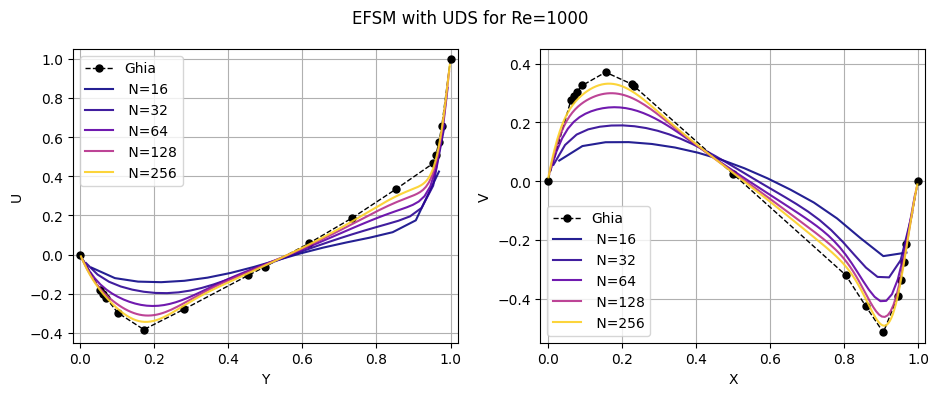

In [127]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
fig,axs=plt.subplots(1,2, figsize=(9.5,4))

sample_dir = {"U":"Y", "V":"X"}
colors = ["red", "red", "blue"]
linestyle=["solid", "dashed", "dashed"]
labels=["EFSM UDS", "EFSM QUICK", "SIMPLE UDS"]

unique_N = sorted(set(case.N for case in select_cases))
norm = mcolors.Normalize(vmin=min(unique_N)*1.1, vmax=max(unique_N)*1.1)
cmap = cm.plasma

select_cases = [cases[1], cases[2], cases[3], cases[4],cases[5]]
for i, (vel, dir) in enumerate(sample_dir.items()):
    ax = axs[i]
    ghia = ghia_dict[vel]
    ax.plot(ghia[dir], ghia[RE], 'o--', color='black',
                label='Ghia', markersize=5, linewidth=1)
    for j, case in enumerate(select_cases):
        vanka_dict = {
            'U': case.ds.sel(x=0.5, method='nearest'),
            'V': case.ds.sel(y=0.5, method='nearest')
        }
        label = f" N={case.N}"

        vanka = vanka_dict[vel]

        ax.plot(vanka[dir], vanka[vel],
                linewidth=1.5,
                label=label, alpha=0.9,
                linestyle="-", color=cmap(norm(case.N)))
    if i==0:
        ax.set_ylim(-0.45,1.05)
    else:
        ax.set_ylim(-0.55,0.45)
    ax.set_xlim(-0.02,1.02)
    ax.set_xlabel(dir)
    ax.set_ylabel(vel)
    ax.legend()
    ax.grid()
    
fig.suptitle(f"EFSM with UDS for Re=1000")
fig.tight_layout()
# handles, labels = axs[0].get_legend_handles_labels()
# fig.legend( handles,labels,ncol=3, loc='upper center', bbox_to_anchor=(0.5, 0))

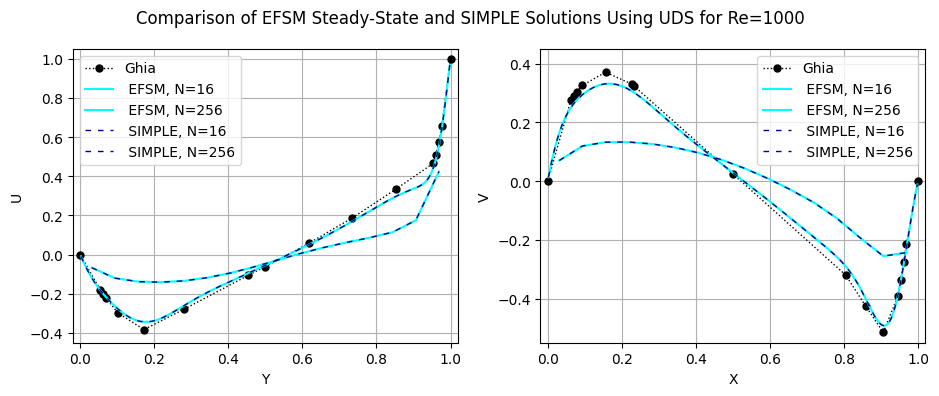

In [191]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
fig,axs=plt.subplots(1,2, figsize=(9.5,4))

sample_dir = {"U":"Y", "V":"X"}
colors = ["red", "red", "blue"]
linestyle_dict={
    "EFSM": 'solid',
    "SIMPLE": (0, (4, 5))
}
colors_dict={
    "EFSM": 'cyan',
    "SIMPLE": 'darkblue'
}
lw_dict={
    "EFSM": 1.5,
    "SIMPLE": 1
}
labels=["EFSM UDS", "EFSM QUICK", "SIMPLE UDS"]

unique_N = sorted(set(case.N for case in select_cases))
norm = mcolors.Normalize(vmin=min(unique_N)*1.1, vmax=max(unique_N)*1.3)
cmap = cm.plasma

select_cases = [cases[1], cases[5], cases[26], cases[30]]
# select_cases = [cases[5],cases[30]]
for i, (vel, dir) in enumerate(sample_dir.items()):
    ax = axs[i]
    ghia = ghia_dict[vel]
    ax.plot(ghia[dir], ghia[RE], 'o',linestyle=":", color='black',
                label='Ghia', markersize=5, linewidth=1)
    for j, case in enumerate(select_cases):
        cutline_dict = {
            'U': case.ds.sel(x=0.5, method='nearest'),
            'V': case.ds.sel(y=0.5, method='nearest')
        }
        solver=case.solution_method
        label = f" {solver}, N={case.N}"

        cutline = cutline_dict[vel]

        ax.plot(cutline[dir], cutline[vel],
                label=label, alpha=1,
                linestyle=linestyle_dict[solver], color=colors_dict[solver], linewidth=lw_dict[solver])
    if i==0:
        ax.set_ylim(-0.45,1.05)
    else:
        ax.set_ylim(-0.55,0.45)
    ax.set_xlim(-0.02,1.02)
    ax.set_xlabel(dir)
    ax.set_ylabel(vel)
    ax.legend()
    ax.grid()
    
fig.suptitle(f"Comparison of EFSM Steady-State and SIMPLE Solutions Using UDS for Re=1000")
fig.tight_layout()
# handles, labels = axs[0].get_legend_handles_labels()
# fig.legend( handles,labels,ncol=3, loc='upper center', bbox_to_anchor=(0.5, 0))